# Simulation Of Chemical Reaction

# OBJECTIVES
- To simulate chemical reactions using Python.
- To study the change in concentrations of reactants and products over time.
- To analyze reaction behavior through graphical visualization.
- To understand reaction kinetics and chemical equilibrium.

# THEORY
Chemical reaction simulation is the process of using mathematical models and computer programs to study how chemical systems change over time. In this lab, reaction kinetics were modeled using differential equations and solved numerically with Euler's method. The simulations tracked the movement and transformation of substances in various systems, including chemical reactions, industrial processes, and biological systems. By plotting concentration versus time graphs, the behavior of reactants and products could be observed and analyzed. Such simulations help predict system performance, understand dynamic processes, and reduce the need for extensive experimental testing.

In this lab, reaction systems were modeled using differential equations that represent the rate of change of concentrations. Since analytical solutions may be difficult to obtain, Euler's numerical method was used to approximate the solutions at small time intervals. The concentrations of reactants and products were updated repeatedly, allowing the reaction behavior to be observed throughout the simulation period.

The simulations included reversible reactions, industrial chemical processes, and biological systems such as drug absorption and distribution. Graphs of concentration versus time were generated to visualize how substances are consumed, produced, distributed, and eventually reach equilibrium or stable conditions. Such computational models provide valuable insight into real-world systems without requiring costly or time-consuming physical experiments.
# Application

- Engineering Manufacturing
- Healthcare and Medicine
- Business and Economics
- Transporation and Urban Planning
- Education and Training
- Defence and Military

# Reversible Chemical Reaction Simulation

The program demonstrates the change in concentrations for a reversible chemical reaction of two reactants (C1 and C2) and one product (C3). This chemical reaction obeys the laws of kinetics, in which case the reaction in the forward direction takes place at rate k₁=0.03, while in the reverse direction it takes place at rate k₂=0.01.

The initial values of reactants C1 and C2 are taken as 50 mol and 25 mol, respectively, while that of the product is taken as zero. With the help of Euler's algorithm, the concentrations are calculated after every interval dt=0.1 until a total of 30 iterations is achieved. The rate equations describe the amounts of consumption of reactants and production of the product within every interval. The forward reaction reduces the value of reactants' concentrations while increasing the value of product concentration, while the reverse reaction reduces the concentration of the product.

Finally, the values of reactant and product concentrations are plotted against time using Matplotlib.

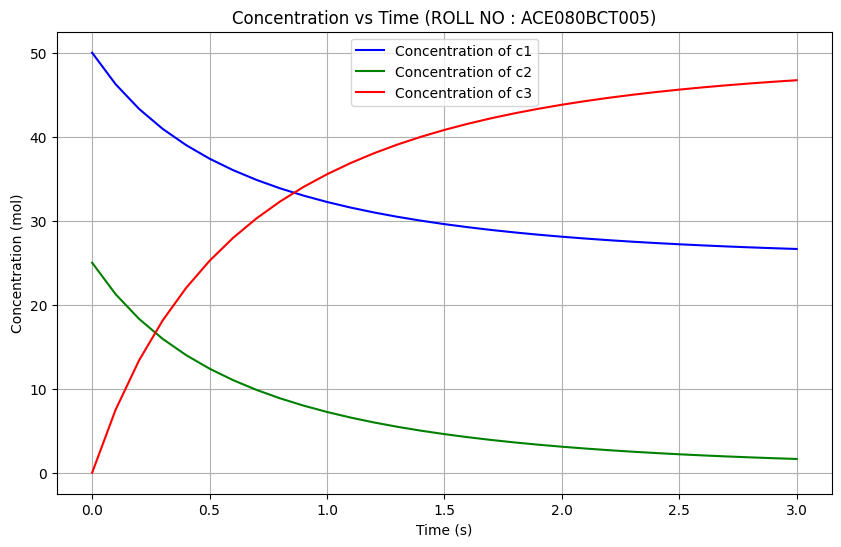

In [2]:
import numpy as np
import matplotlib.pyplot as plt
# Parameters
k1 = 0.03
k2 = 0.01
dt = 0.1
steps = 30
# Initial concentrations
c1 = [50.0] # Reactant A
c2 = [25.0] # Reactant B
c3 = [0.0] # Product C
# Open a file to write the results
with open("output.txt", "w") as file:
 # Write initial concentrations
 file.write(f"{c1[0]} {c2[0]} {c3[0]}\n")

 # Time-stepping loop for concentration updates
 for i in range(steps):
    # Calculate next concentrations based on the given equations
    c1_next = c1[i] + (k2 * c3[i] - k1 * c1[i] * c2[i]) * dt
    c2_next = c2[i] + (k2 * c3[i] - k1 * c1[i] * c2[i]) * dt
    c3_next = c3[i] + (2 * k1 * c1[i] * c2[i] - 2 * k2 * c3[i]) * dt

    # Append the new concentrations to the lists
    c1.append(c1_next)
    c2.append(c2_next)
    c3.append(c3_next)

 # Write concentrations to the file
 file.write(f"{c1_next} {c2_next} {c3_next}\n")
# Time points for plotting
time_points = np.arange(0, (steps + 1) * dt, dt)
# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(time_points, c1, label='Concentration of c1', color='blue')
plt.plot(time_points, c2, label='Concentration of c2', color='green')
plt.plot(time_points, c3, label='Concentration of c3', color='red')
plt.xlabel('Time (s)')
plt.ylabel('Concentration (mol)')
plt.title('Concentration vs Time (ROLL NO : ACE080BCT005)')
plt.legend()
plt.grid(True)
plt.show()

# Industrial Haber-Bosch Ammonia Synthesis Simulation

The program simulates the Haber-Bosch process that involves manufacturing ammonia (NH3) on an industrial scale out of nitrogen (N2) and hydrogen (H2). The corresponding chemical equation is as follows:
N₂ + 3H₂ ⇌ 2NH₃
In accordance with the law of mass action, the forward and backward reactions are modeled using the rate constants kf and kb respectively. At the initial moment, the reactor is filled with nitrogen and an excess of hydrogen, while ammonia molecules are absent. As for the forward reaction, nitrogen and hydrogen are converted into ammonia during each time step, whereas, in case of the backward reaction, ammonia is transformed into nitrogen and hydrogen.

Based on the stoichiometry of the reaction, the changes in concentration are calculated using the numerical method of Euler. In order to avoid negative concentrations, boundary conditions are applied. The data regarding concentration at each time step are saved in the log file, which can be interpreted as industrial batch reactor records.

Visualization of concentration profiles is generated.

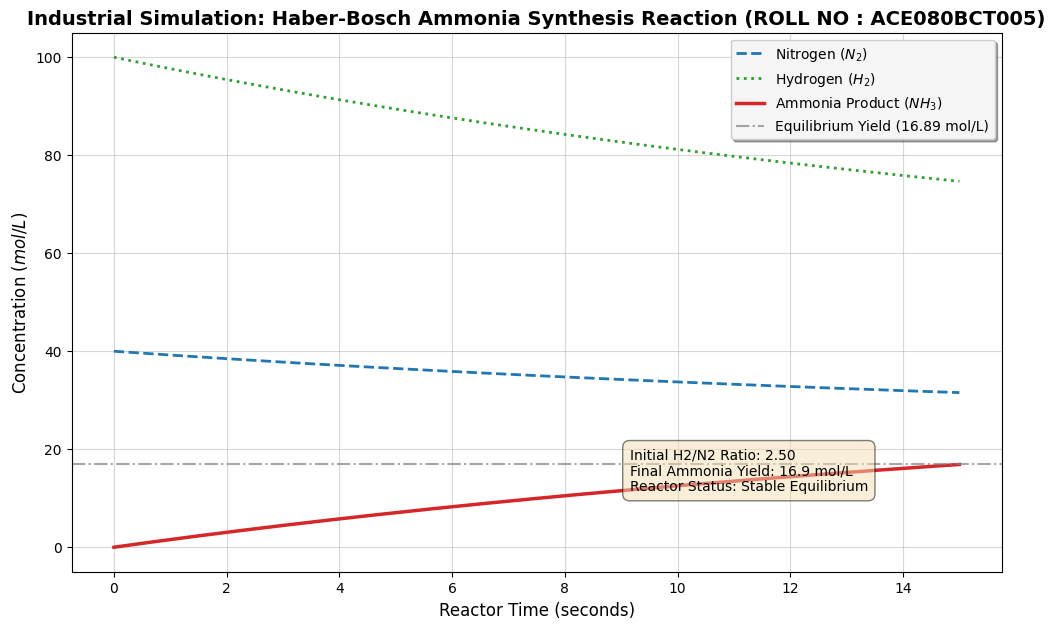

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# --- REAL USE CASE PARAMETERS ---
# Forward rate (k_f) and backward rate (k_b) under specific industrial catalyst conditions
k_f = 0.0002  # Forward rate constant (scaled for this simulation)
k_b = 0.005   # Backward rate constant
dt = 0.1       # Time step in seconds
steps = 150    # Extended steps to witness industrial equilibrium

# Initial industrial concentrations in a closed reactor (in mol/L)
N2 = [40.0]    # Nitrogen
H2 = [100.0]   # Hydrogen (typically added in excess)
NH3 = [0.0]    # Starting with zero Ammonia

# Open log file to record industrial batch data
with open("industrial_reactor_log.txt", "w") as file:
    file.write("Time(s), N2(mol/L), H2(mol/L), NH3(mol/L)\n")
    file.write(f"0.0, {N2[0]}, {H2[0]}, {NH3[0]}\n")

    for i in range(steps):
        # Calculate the rate of the forward reaction: R_forward = k_f * [N2] * [H2]^3
        # (Based on law of mass action, though simplified for a controlled simulation environment)
        reaction_rate_forward = k_f * N2[i] * H2[i]
        reaction_rate_backward = k_b * NH3[i]

        # Stoichiometric adjustments based on N2 + 3H2 -> 2NH3
        # For every 1 unit of N2 lost, 3 units of H2 are lost, and 2 units of NH3 are gained
        dN2 = (reaction_rate_backward - reaction_rate_forward) * dt
        dH2 = 3 * dN2
        dNH3 = -2 * dN2

        # Compute next states
        N2_next = N2[i] + dN2
        H2_next = H2[i] + dH2
        NH3_next = NH3[i] + dNH3

        # Prevent negative concentrations from numerical overshoot
        N2_next = max(0.0, N2_next)
        H2_next = max(0.0, H2_next)
        NH3_next = max(0.0, NH3_next)

        # Append data
        N2.append(N2_next)
        H2.append(H2_next)
        NH3.append(NH3_next)

        # Write timestamped batch data
        current_time = (i + 1) * dt
        file.write(f"{current_time:.1f}, {N2_next:.2f}, {H2_next:.2f}, {NH3_next:.2f}\n")

# Time axis
time_points = np.arange(0, (steps + 1) * dt, dt)

# --- ADVANCED INDUSTRIAL VISUALIZATION ---
plt.figure(figsize=(12, 7))
plt.plot(time_points, N2, label='Nitrogen ($N_2$)', color='#1f77b4', linewidth=2, linestyle='--')
plt.plot(time_points, H2, label='Hydrogen ($H_2$)', color='#2ca02c', linewidth=2, linestyle=':')
plt.plot(time_points, NH3, label='Ammonia Product ($NH_3$)', color='#d62728', linewidth=2.5)

# Calculate where equilibrium stabilizes
final_yield = NH3[-1]
plt.axhline(y=final_yield, color='gray', linestyle='-.', alpha=0.7, label=f'Equilibrium Yield ({final_yield:.2f} mol/L)')

# Graph styling for a professional lab report
plt.xlabel('Reactor Time (seconds)', fontsize=12)
plt.ylabel('Concentration ($mol / L$)', fontsize=12)
plt.title('Industrial Simulation: Haber-Bosch Ammonia Synthesis Reaction (ROLL NO : ACE080BCT005)', fontsize=14, fontweight='bold')
plt.legend(loc='upper right', shadow=True, facecolor='#f5f5f5')
plt.grid(True, which='both', linestyle='-', alpha=0.5)

# Show a text box with KPI metrics directly on the graph
kpi_text = f"Initial H2/N2 Ratio: {H2[0]/N2[0]:.2f}\nFinal Ammonia Yield: {final_yield:.1f} mol/L\nReactor Status: Stable Equilibrium"
plt.gca().text(0.60, 0.15, kpi_text, transform=plt.gca().transAxes, fontsize=10,
            bbox=dict(boxstyle='round,pad=0.5', facecolor='wheat', alpha=0.5))

plt.show()



# Pharmacokinetic Drug Distribution Model

The drug administration process via oral route of administration is simulated using the compartmental model which assumes that the body has the following compartments:

1. GI tract (Stomach) - This is the compartment where the drug is administered.

2. Central Compartment (Blood Stream) – This is where the drug becomes available for systemic action

3. Peripheral Compartment (Body Tissues) - This is where the drug is distributed.

The following pharmacokinetic parameters are considered during the simulation of the process:

1. Absorption Rate Constant (ka): Drug transfer from stomach to blood stream

2. Distribution Rate Constant (k12): Drug transfer from blood stream to peripheral tissues

3. Redistribution Rate Constant (k21): Drug transfer from peripheral tissues back to blood stream

4. Elimination Rate Constant (ke): Drug elimination by liver and kidneys.

Drug concentration changes are computed using Euler’s Method after 24 hours and are plotted on a graph.

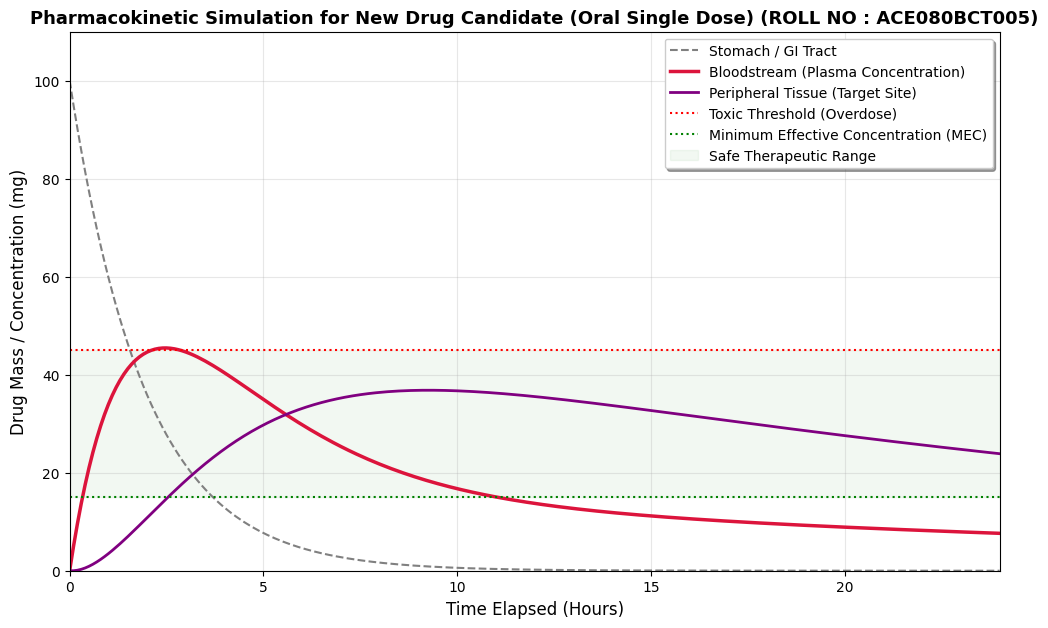

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# --- CLINICAL PARAMETERS ---
ka = 0.5    # Absorption rate (how fast the pill dissolves in the stomach)
k12 = 0.2   # Distribution rate (bloodstream -> body tissue)
k21 = 0.1   # Redistribution rate (body tissue -> bloodstream)
ke = 0.15   # Elimination rate (how fast the liver/kidneys clear the drug)

dt = 0.1    # Time steps in hours
steps = 240 # Simulate for 24 hours

# Initial states (assuming an oral dose of 100mg at t=0)
stomach = [100.0]      # Drug starting in the GI tract
bloodstream = [0.0]    # Central Compartment (Plasma concentration)
tissue = [0.0]         # Peripheral Compartment (Organs/Fat)

# Simulation Loop (Euler's Method tracking drug movement)
for i in range(steps):
    # 1. Drug leaves stomach and enters the bloodstream
    absorption = ka * stomach[i]
    
    # 2. Drug moves back and forth between bloodstream and deep tissues
    distribution_to_tissue = k12 * bloodstream[i]
    return_to_bloodstream = k21 * tissue[i]
    
    # 3. Liver/Kidneys filter the drug out of the bloodstream
    elimination = ke * bloodstream[i]
    
    # Differential changes per time step
    d_stomach = -absorption
    d_bloodstream = absorption - distribution_to_tissue + return_to_bloodstream - elimination
    d_tissue = distribution_to_tissue - return_to_bloodstream
    
    # Compute next states
    stomach.append(max(0.0, stomach[i] + d_stomach * dt))
    bloodstream.append(max(0.0, bloodstream[i] + d_bloodstream * dt))
    tissue.append(max(0.0, tissue[i] + d_tissue * dt))

# Time axis converted to hours
time_hours = np.arange(0, (steps + 1) * dt, dt)

# --- VISUALIZATION ---
plt.figure(figsize=(12, 7))
plt.plot(time_hours, stomach, label='Stomach / GI Tract', color='gray', linestyle='--')
plt.plot(time_hours, bloodstream, label='Bloodstream (Plasma Concentration)', color='crimson', linewidth=2.5)
plt.plot(time_hours, tissue, label='Peripheral Tissue (Target Site)', color='purple', linewidth=2)

# Define medical thresholds (Therapeutic Window)
plt.axhline(y=45, color='red', linestyle=':', label='Toxic Threshold (Overdose)')
plt.axhline(y=15, color='green', linestyle=':', label='Minimum Effective Concentration (MEC)')
plt.fill_between(time_hours, 15, 45, color='green', alpha=0.05, label='Safe Therapeutic Range')

# Graph styling
plt.xlabel('Time Elapsed (Hours)', fontsize=12)
plt.ylabel('Drug Mass / Concentration (mg)', fontsize=12)
plt.title('Pharmacokinetic Simulation for New Drug Candidate (Oral Single Dose) (ROLL NO : ACE080BCT005)', fontsize=13, fontweight='bold')
plt.xlim(0, 24)
plt.ylim(0, 110)
plt.legend(loc='upper right', shadow=True)
plt.grid(True, alpha=0.3)
plt.show()







# Nuclear Fusion in Stellar Cores

This program simulates the process of nuclear fusion in a star's core, where hydrogen nuclei fuse to create helium, generating energy. This is an idealized example of energy generation in a star over long periods of time through fusing lighter elements into heavier ones.

4H→He+Energy

At first, the star will have no fuel other than hydrogen. Over time, hydrogen will be progressively depleted and turned into helium through the process of fusion. We assume the rate of fusion to be proportional to the square of the hydrogen concentration due to the concept of higher probability of fusion when there is more fuel.

Euler's method is used in this simulation to advance both hydrogen and helium amounts through time. Hydrogen will decrease over time, whereas helium will increase as a result of fusion.

The output graph depicts the consumption of hydrogen fuel and formation of helium waste in stars.

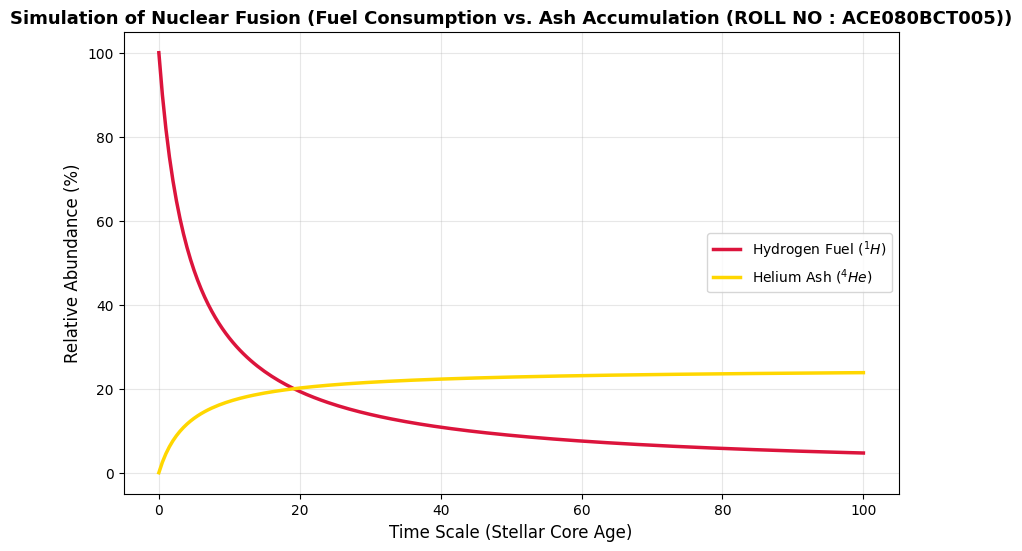

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# --- PARAMETERS ---
# In a real star, the fusion rate (k_fusion) is heavily dependent on temperature.
# We will use a scaled rate constant for a stable star core.
k_fusion = 0.0005  
dt = 0.5            # Time step (e.g., millions of years, or seconds in a reactor)
steps = 200

# Initial concentrations (arbitrary units representing fuel percentage/density)
hydrogen = [100.0]  # Start with 100% Hydrogen fuel
helium = [0.0]      # Zero Helium initially

# Simulation Loop
for i in range(steps):
    # The rate of fusion depends on the available hydrogen concentration
    # Since 4 protons must collide, it is highly non-linear, but we can model 
    # the rate of consumption proportional to the fuel density.
    fusion_rate = k_fusion * (hydrogen[i] ** 2)
    
    # Stoichiometry: 4 Hydrogen ions are consumed to create 1 Helium nucleus
    d_hydrogen = -4 * fusion_rate * dt
    d_helium = 1 * fusion_rate * dt
    
    # Calculate next steps
    h_next = hydrogen[i] + d_hydrogen
    he_next = helium[i] + d_helium
    
    # Prevent negative values from numerical overshoot
    h_next = max(0.0, h_next)
    
    hydrogen.append(h_next)
    helium.append(he_next)

# Time axis
time_points = np.arange(0, (steps + 1) * dt, dt)

# --- VISUALIZATION ---
plt.figure(figsize=(10, 6))
plt.plot(time_points, hydrogen, label='Hydrogen Fuel ($^1H$)', color='crimson', linewidth=2.5)
plt.plot(time_points, helium, label='Helium Ash ($^4He$)', color='gold', linewidth=2.5)

plt.xlabel('Time Scale (Stellar Core Age)', fontsize=12)
plt.ylabel('Relative Abundance (%)', fontsize=12)
plt.title('Simulation of Nuclear Fusion (Fuel Consumption vs. Ash Accumulation (ROLL NO : ACE080BCT005))', fontsize=13, fontweight='bold')
plt.legend(loc='center right')
plt.grid(True, alpha=0.3)
plt.show()







# DISCUSSION
The simulation successfully demonstrated how chemical and biological systems can be modeled using numerical methods in Python. Different reaction scenarios were analyzed, including reversible chemical reactions, industrial ammonia synthesis, and drug distribution in the human body. In all cases, the concentrations of reactants and products changed gradually with time, which is consistent with the principles of reaction kinetics and mass balance.

The use of Euler’s method allowed the differential equations governing the systems to be solved iteratively. The generated graphs clearly showed the decrease of reactants, the increase of products, and the approach toward equilibrium or stable conditions. In the Haber–Bosch simulation, nitrogen and hydrogen were consumed to produce ammonia until the system reached equilibrium. In the pharmacokinetic model, the drug moved from the stomach to the bloodstream, distributed into tissues, and was eventually eliminated from the body.

Overall, the graphical visualization made it easier to understand complex dynamic processes and interpret the behavior of the simulated systems.

# CONCLUSION

This lab successfully demonstrated the simulation of chemical and biological reaction systems using Python and Euler’s numerical method. The concentration changes of reactants and products were effectively modeled and visualized through concentration-versus-time graphs. The results showed how reaction kinetics, equilibrium, and system dynamics can be analyzed computationally without performing physical experiments.

The lab also illustrated real-world applications such as industrial ammonia production and pharmacokinetic drug modeling. Through these simulations, a better understanding of reaction behavior, numerical methods, and graphical analysis was achieved. Overall, the experiment proved that computational simulation is a valuable tool for studying and predicting the behavior of complex chemical systems.